In [211]:
import torch 
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns



In [212]:
def rbf(x1,x2,amplitude = 1.0,length_scale = 1.0):
    """ 
    Gaussian kernel 
    input --> x1(n1,) and x2(n2)
    output --> (n1,n2) dim     
    
    """
    x1 = x1.flatten()
    x2 = x2.flatten()
    
    square_dist = (x1[:,np.newaxis] - x2[np.newaxis,:])**2 # pair-wise square
    return amplitude*np.exp(-square_dist/(2*length_scale**2))

x = np.array([1,2,75,80])
rbf(x,x)
rbf(np.array([[3]]),x)
    
    
def sample_gp(K,number_sample = 4):
    mean = np.zeros((K.shape[0]))
    I = np.identity(K.shape[0])
    L = np.linalg.cholesky(K)
    samples = np.random.multivariate_normal(mean,I,number_sample).dot(L)
    return samples

    

    
    

[[-7.13766578e-01 -3.32050629e-01  1.66334876e-01  3.98912505e-01
   6.38039337e-01  6.32783041e-01  7.35830957e-01  9.35409376e-01
   1.02141897e+00  1.00931840e+00  1.03970655e+00  1.12963816e+00
   1.18454357e+00  1.17061582e+00  1.14231807e+00  1.14514223e+00
   1.16594926e+00  1.16477520e+00  1.13711285e+00  1.11277863e+00
   1.10571444e+00  1.10746512e+00  1.10141373e+00  1.07750075e+00
   1.05196743e+00  1.02895148e+00  9.95097660e-01  9.46337941e-01
   8.72313430e-01  7.79255203e-01  6.74414772e-01  5.51587925e-01
   4.16613677e-01  2.71900059e-01  1.23329749e-01 -1.67262417e-02
  -1.45043096e-01 -2.54164349e-01 -3.36782170e-01 -3.88518971e-01
  -4.05997678e-01 -3.87490558e-01 -3.34493290e-01 -2.45719679e-01
  -1.28378093e-01  2.02915901e-02  1.87454453e-01  3.77282815e-01
   5.81330974e-01  7.92871092e-01  1.00506642e+00  1.21736011e+00
   1.42010982e+00  1.60824107e+00  1.77435114e+00  1.91211310e+00
   2.01648695e+00  2.08109968e+00  2.10251917e+00  2.08054944e+00
   2.01497

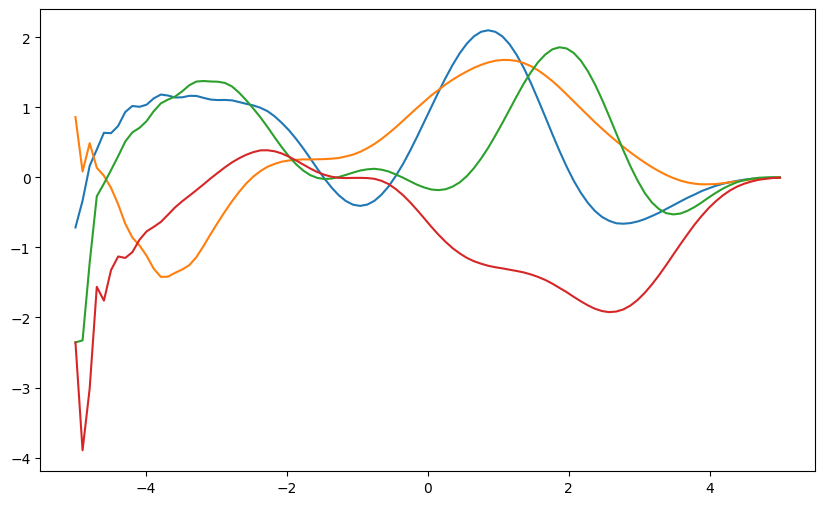

In [213]:
# Ssampling functions from G.P
X = np.linspace(-5,5,100).reshape(-1,1)
K = rbf(X,X)
K += 1e-6*np.eye(K.shape[0])   # adding some error variance
samples = sample_gp(K)
print(samples)
print(samples.shape)
# plot the samples 
plt.figure(figsize=(10,6))
for i,sample in enumerate(samples):
    plt.plot(X,sample,label=f'Sample {i + 1}') 

In [214]:
K = rbf(x,x)
L = np.linalg.cholesky(K)
mean = np.zeros((K.shape[0]))
I = np.identity(K.shape[0])
np.random.seed(42)
f = np.random.multivariate_normal(mean,K)

f

array([-1.12071699,  0.23035616, -0.3602163 ,  0.55575191])

In [215]:
I = np.identity(K.shape[0])
np.random.seed(42)
f = np.random.multivariate_normal(mean,I).dot(L)
f

array([ 0.41285262, -0.10992843,  0.64769421,  1.52302986])

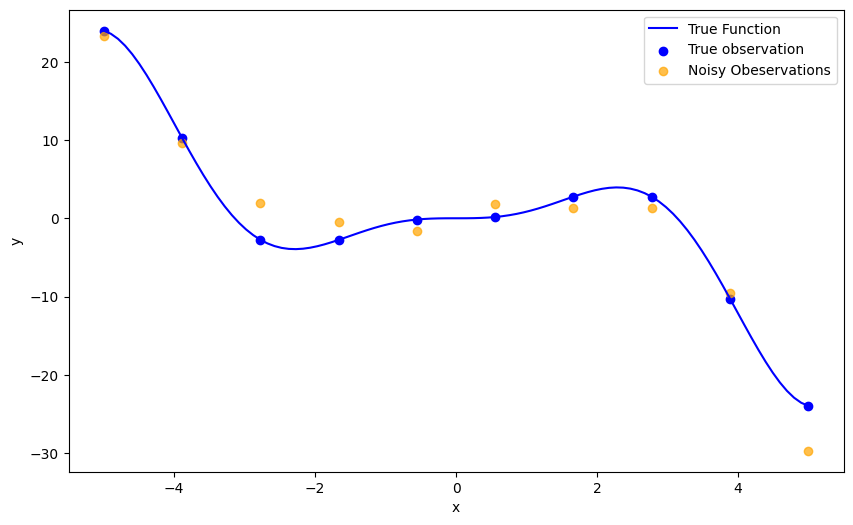

In [216]:
def generate_noise_data(true_function,n_data = 10,noise_std = 3):
    x = np.linspace(-5,5,n_data)
    true_function = true_function(x)
    # true_function = np.sin(x)*x**2
    # true_function = 2*np.sin(x)*np.exp(-x**2 + x) #a*x**3 +b*x**2 +c*x + d

    y = true_function + np.random.normal(0,noise_std,n_data)
    #reshape for GP consistency
    x = x.reshape(-1,1) # x[:,np.newaxis]
    y = y.reshape(-1,1)
    return x,y,true_function
#plot data 
true_function = lambda x: np.sin(x)*x**2
x_cont = np.linspace(-5,5,100)
X,y,true_y = generate_noise_data(true_function)
fs =  true_function(x_cont)
plt.figure(figsize=(10,6))
plt.plot(x_cont,fs,label="True Function", color='blue')
plt.scatter(X,true_y,label="True observation ", color='blue')
plt.scatter(X,y,label="Noisy Obeservations",color='orange',alpha=0.7)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()    

In [217]:
true_function = lambda x:np.sin(x)*np.exp(-x**2)
X,y,true_y = generate_noise_data(true_function,20)
X_train,Xtest = X[::+2],X[1::+2]
y_train,ytest = y[::+2],y[1::+2]
f_train,ftest = f[::+2],f[1::+2]
K = rbf(X_train,X_train)
K += 1e-6*np.eye(K.shape[0]) 
samples = sample_gp(K)
x_ = np.array(Xtest[5])
k_ = rbf(X_train,x_) 
k__ = rbf(x_,x_)
# m = K.inv*f --> solving Km = f linear eqation 
m = np.linalg.solve(K,y_train)
mue_ = k_.T.dot(m)
sigma_ = k__ - k_.T.dot(np.linalg.solve(K,k_))







More regorous implementation

In [218]:
import numpy as np
import matplotlib.pyplot as plt

X shape: (20, 1), y shape: (20, 1), true_y shape: (20,)
X_train shape: (10, 1), y_train shape: (10, 1)
X_test shape: (10, 1), y_test shape: (10, 1)
K shape: (10, 10)
Samples shape: (4, 10)
x_test shape: (1, 1)
k_ shape: (10, 1)
k__ shape: (1, 1)
m shape: (10, 1)
mu_ shape: (1, 1)
sigma_ shape: (1, 1)
(1, 1)


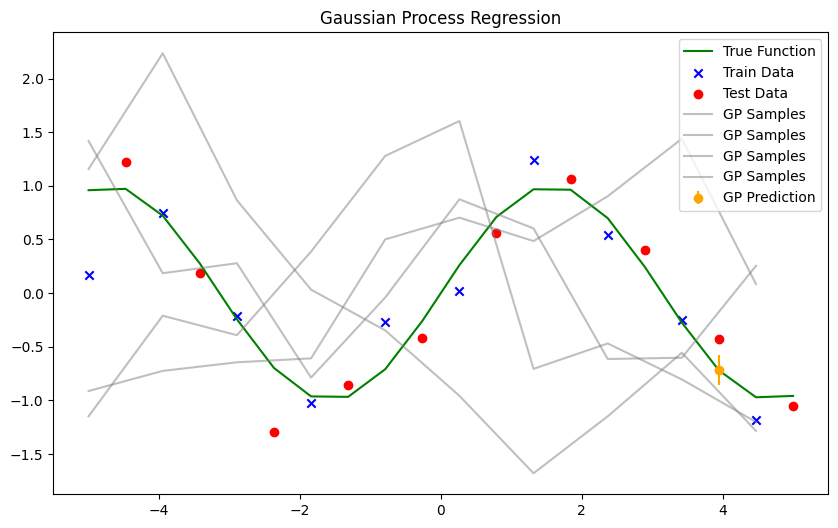

In [219]:

def rbf(x1, x2, amplitude=1.0, length_scale=1.0):
    """
    Radial Basis Function (Gaussian Kernel)
    Args:
        x1: array-like, shape (n1,)
        x2: array-like, shape (n2,)
    Returns:
        Kernel matrix of shape (n1, n2)
    """
    x1 = x1.flatten()
    x2 = x2.flatten()
    square_dist = (x1[:, np.newaxis] - x2[np.newaxis, :]) ** 2  # pair-wise squared distances
    return amplitude * np.exp(-square_dist / (2 * length_scale ** 2))

def sample_gp(K,number_sample=4):
    """
    Generate samples from a Gaussian Process
    Args:
        K: Covariance matrix
        num_samples: Number of samples to generate
    Returns:
        Samples from the GP
    """
    mean = np.zeros(K.shape[0])
    samples = np.random.multivariate_normal(mean,K,number_sample)
    print(f"Samples shape: {samples.shape}")
    return samples

def generate_noise_data(true_function,n_data=10,noise_std=0.5):
    """
    Generate noisy data from the true function
    Args:
        true_function: Function to generate the data
        n_data: Number of data points
        noise_std: Standard deviation of Gaussian noise
    Returns:
        x: Input data
        y: Noisy observations
        true_y: True function values
    """
    x = np.linspace(-5, 5, n_data)
    true_y = true_function(x)
    y = true_y + np.random.normal(0, noise_std, n_data)
    return x.reshape(-1, 1), y.reshape(-1, 1), true_y


# Define the true function 
true_function = lambda x: np.sin(x)

#Generate Data
X, y, true_y = generate_noise_data(true_function, n_data=20, noise_std=0.3)
print(f"X shape: {X.shape}, y shape: {y.shape}, true_y shape: {true_y.shape}")

X_train, X_test = X[::2], X[1::2]
y_train, y_test = y[::2], y[1::2]
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")
# Compute the covariance
K = rbf(X_train,X_train) # (n,n)
Ky = K + 1e-6*np.eye(K.shape[0])
print(f"K shape: {K.shape}")

# Sample from Gaussian 
samples = sample_gp(Ky)

x_test = np.array(X_test[8]).reshape(-1,1)
print(f"x_test shape: {x_test.shape}")

k_ = rbf(X_train,x_test)
print(f"k_ shape: {k_.shape}")

k__ = rbf(x_test,x_test)
print(f"k__ shape: {k__.shape}")

# Solve for mean and Variance 
m = np.linalg.solve(K,y_train)
print(f"m shape: {m.shape}")

mu_ = k_.T.dot(m) #Posterior mean
print(f"mu_ shape: {mu_.shape}")


# Solve for posterior variance 
alpha =np.linalg.solve(K,k_)
sigma_ = k__ - k_.T.dot(alpha)
print(f"sigma_ shape: {sigma_.shape}")

print(sigma_.shape)

#Plot the result
plt.figure(figsize=(10, 6))
plt.plot(X.flatten(), true_y, label="True Function", color="green")
plt.scatter(X_train, y_train, label="Train Data", color="blue", marker="x")
plt.scatter(X_test, y_test, label="Test Data", color="red", marker="o")
plt.plot(X_train, samples.T, alpha=0.5, label="GP Samples", color="gray")
plt.errorbar(x_test.flatten(), mu_, yerr=np.sqrt(sigma_), fmt='o', color='orange', label="GP Prediction")
plt.title("Gaussian Process Regression")
plt.legend()
plt.show()







    
    
    
    
    

